# Provider Billing Review and Investigation Prioritization

Business-facing review package for compliance leadership, audit, and investigation operations. The analysis uses a SynPUF-style provider integrity dataset to prioritize providers for review based on atypical, financially material, and explainable billing behavior.

The target variable is `review_flag`, where `1` indicates a provider should be prioritized for program-integrity review and `0` indicates that the provider is not prioritized. Provider identifiers and injected typology labels are excluded from model fitting to prevent leakage; they are used only for audit, validation, and reviewer handoff.

## Decision problem and legal boundary

The output of this workflow is a screening and triage queue. It is not a fraud finding, payment suspension recommendation, overpayment determination, or enforcement decision. Any escalation must be supported by claim-line corroboration, documented reviewer judgment, and applicable compliance procedures.

The governance goal is to answer five practical questions:

1. Is the queue useful for compliance operations?
2. Does the queue concentrate known review-merit cases and financial exposure?
3. Which billing indicators explain case selection?
4. Which typologies and specialties require reviewer attention?
5. What controls are needed before operational deployment?

## 1. Environment and reproducibility setup

The notebook uses HUG-IML as the modeling API and keeps the modeling specification explicit: predictors are declared in one place, leakage fields are excluded, and the decision threshold is selected against a precision constraint for false-positive control.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

try:
    from hugiml import HUGIMLClassifier
except ImportError as exc:
    raise ImportError("This notebook requires hugiml-core. Install it with: pip install hugiml-core") from exc

RANDOM_STATE = 41
MIN_PRIORITY_PRECISION = 0.84

DATA_PATH = Path("nb10_medicare_program_integrity_data.csv")
METADATA_PATH = Path("nb10_medicare_program_integrity_metadata.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

PREDICTORS = [
    "specialty",
    "region",
    "beneficiary_count",
    "claims_per_beneficiary",
    "avg_allowed_amount",
    "risk_adjustment_score",
    "high_level_code_rate",
    "duplicate_claim_rate",
    "modifier_59_rate",
    "weekend_service_rate",
    "denial_rate",
    "referral_concentration",
    "peer_z_allowed",
    "total_allowed_amount",
]
TARGET = "review_flag"
LEAKAGE_EXCLUSIONS = ["provider_id", "injected_typology"]


def choose_threshold(y_true, y_score, min_precision=0.84):
    """Select the highest-recall threshold satisfying a minimum precision constraint."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    valid = np.where(precision[:-1] >= min_precision)[0]
    if len(valid):
        best = valid[np.argmax(recall[:-1][valid])]
        return float(thresholds[best]), "minimum_precision"
    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    return float(thresholds[np.argmax(f1)]), "fallback_f1"


def pct(x):
    return f"{100 * x:,.1f}%"


def money(x):
    return f"${x:,.0f}"

## 2. Load data and metadata

The metadata register is used as a lightweight governance dictionary. It documents the role of each field, whether it is used in the model, and how the field should be interpreted during review.

In [2]:
df = pd.read_csv(DATA_PATH)
metadata = pd.read_csv(METADATA_PATH)

required_columns = set(PREDICTORS + [TARGET] + LEAKAGE_EXCLUSIONS)
missing = sorted(required_columns.difference(df.columns))
if missing:
    raise ValueError(f"Missing required columns: {missing}")

summary = pd.DataFrame({
    "record_count": [len(df)],
    "provider_count": [df["provider_id"].nunique()],
    "target_rate": [df[TARGET].mean()],
    "specialties": [df["specialty"].nunique()],
    "regions": [df["region"].nunique()],
    "total_allowed_amount": [df["total_allowed_amount"].sum()],
})
summary_fmt = summary.copy()
summary_fmt["target_rate"] = summary_fmt["target_rate"].map(pct)
summary_fmt["total_allowed_amount"] = summary_fmt["total_allowed_amount"].map(money)
display(summary_fmt)

display(df.head(8))

,record_count,provider_count,target_rate,specialties,regions,total_allowed_amount
0,7000,7000,10.7%,9,4,"$3,460,879,222"


,provider_id,specialty,region,beneficiary_count,claims_per_beneficiary,avg_allowed_amount,risk_adjustment_score,high_level_code_rate,duplicate_claim_rate,modifier_59_rate,weekend_service_rate,denial_rate,referral_concentration,peer_z_allowed,total_allowed_amount,injected_typology,review_flag
0,NPI2000000000,Internal Medicine,Northeast,92,5.6500,480.8700,0.9800,0.0730,0.0860,0.1480,0.0190,0.0710,0.2130,-0.9400,"245,871.4600",No injected typology,0
1,NPI2000000001,Pain Management,South,406,6.8300,253.6800,0.9100,0.1890,0.0060,0.0510,0.0770,0.0100,0.5930,-0.7700,"637,624.0000",No injected typology,0
2,NPI2000000002,Home Health,Northeast,221,4.8200,297.3400,0.6200,0.5280,0.0200,0.1570,0.0610,0.1900,0.2880,0.4300,"196,943.4600",No injected typology,0
3,NPI2000000003,Internal Medicine,Northeast,106,6.7000,230.9600,0.6400,0.2820,0.0370,0.1380,0.0060,0.0590,0.2380,0.0300,"105,051.9100",No injected typology,0
4,NPI2000000004,Internal Medicine,Northeast,154,5.9200,436.1500,0.9800,0.1130,0.0690,0.1380,0.0900,0.2530,0.4180,1.1800,"387,960.7500",No injected typology,0
5,NPI2000000005,Oncology,Midwest,312,3.3400,609.6300,1.0500,0.2610,0.0470,0.0050,0.0590,0.0510,0.0600,0.4400,"664,346.0900",No injected typology,0
6,NPI2000000006,Internal Medicine,Northeast,191,4.9300,572.2300,1.0500,0.2420,0.0100,0.0280,0.0340,0.1120,0.2990,-0.7300,"566,640.6500",No injected typology,0
7,NPI2000000007,Internal Medicine,Northeast,477,7.7500,377.8500,0.8100,0.1850,0.0380,0.0290,0.1420,0.1060,0.1000,-0.1700,"1,124,747.9000",No injected typology,0


In [3]:
feature_register = metadata.copy()
feature_register["modeling_status"] = np.where(
    feature_register["column_name"].isin(PREDICTORS),
    "Predictor",
    np.where(feature_register["column_name"].isin(LEAKAGE_EXCLUSIONS), "Excluded from model", "Target or reference")
)
feature_register = feature_register[[
    "column_name", "role", "data_type", "modeling_status", "description", "governance_note"
]]
display(feature_register)
feature_register.to_csv(OUTPUT_DIR / "feature_governance_register.csv", index=False)

,column_name,role,data_type,modeling_status,description,governance_note
0,provider_id,identifier,string,Excluded from model,Synthetic provider identifier.,Excluded from model; used for investigation tr...
1,specialty,predictor,categorical,Predictor,Provider specialty peer group.,Necessary for specialty-adjusted interpretation.
2,region,predictor,categorical,Predictor,Provider region.,Monitoring dimension; should not be overinterp...
3,beneficiary_count,predictor,integer,Predictor,Approximate provider panel size.,Volume context for billing intensity.
4,claims_per_beneficiary,predictor,numeric,Predictor,Billing intensity per beneficiary.,Potential overutilization signal.
5,avg_allowed_amount,predictor,numeric,Predictor,Average allowed amount per claim/service.,Cost-intensity signal.
6,risk_adjustment_score,predictor,numeric,Predictor,Case-mix adjustment proxy.,Helps avoid penalizing clinically complex panels.
7,high_level_code_rate,predictor,numeric,Predictor,Share of high-level billing codes.,Upcoding-style signal.
8,duplicate_claim_rate,predictor,numeric,Predictor,Duplicate-claim pattern rate.,Potential duplicate billing signal.
9,modifier_59_rate,predictor,numeric,Predictor,Modifier use rate related to unbundling review.,Potential unbundling signal.


## 3. Data quality and baseline distribution

The validation checks focus on records, missingness, target prevalence, field roles, and validation-only typology labels. The injected typology field is useful for evaluating whether the screening queue captures known pattern families, but it is not used as a predictor.

In [4]:
missingness = (
    df.isna().mean()
    .rename("missing_rate")
    .reset_index()
    .rename(columns={"index": "column_name"})
    .sort_values("missing_rate", ascending=False)
)

numeric_profile = df[PREDICTORS].select_dtypes(include=[np.number]).describe().T
numeric_profile = numeric_profile[["mean", "std", "min", "25%", "50%", "75%", "max"]]

typology_baseline = df.groupby("injected_typology", observed=True).agg(
    providers=("provider_id", "count"),
    review_flag_rate=(TARGET, "mean"),
    total_allowed=("total_allowed_amount", "sum"),
).reset_index().sort_values("review_flag_rate", ascending=False)

typology_display = typology_baseline.copy()
typology_display["review_flag_rate"] = typology_display["review_flag_rate"].map(pct)
typology_display["total_allowed"] = typology_display["total_allowed"].map(money)

display(Markdown("**Missingness check**"))
display(missingness.head(20))
display(Markdown("**Numeric predictor profile**"))
display(numeric_profile)
display(Markdown("**Validation typology baseline**"))
display(typology_display)

**Missingness check**

,column_name,missing_rate
0,provider_id,0.0000
1,specialty,0.0000
2,region,0.0000
3,beneficiary_count,0.0000
4,claims_per_beneficiary,0.0000
5,avg_allowed_amount,0.0000
6,risk_adjustment_score,0.0000
7,high_level_code_rate,0.0000
8,duplicate_claim_rate,0.0000
9,modifier_59_rate,0.0000


**Numeric predictor profile**

,mean,std,min,25%,50%,75%,max
beneficiary_count,194.2079,125.6881,30.0000,109.0000,164.0000,240.0000,"1,200.0000"
claims_per_beneficiary,6.2034,1.4964,1.0000,5.2200,6.1900,7.2200,13.5100
avg_allowed_amount,399.6219,203.4805,79.8500,258.7150,355.4400,491.7650,"2,085.3800"
risk_adjustment_score,1.0290,0.2174,0.5500,0.8775,1.0300,1.1800,1.9800
high_level_code_rate,0.2172,0.1585,0.0020,0.1080,0.1855,0.2830,1.0000
duplicate_claim_rate,0.0475,0.0628,0.0000,0.0160,0.0320,0.0563,0.6790
modifier_59_rate,0.1318,0.1365,0.0000,0.0510,0.0970,0.1630,1.0000
weekend_service_rate,0.0755,0.1002,0.0000,0.0220,0.0490,0.0940,0.9840
denial_rate,0.1167,0.0829,0.0010,0.0560,0.0990,0.1590,0.7670
referral_concentration,0.2496,0.1446,0.0030,0.1370,0.2260,0.3423,0.8360


**Validation typology baseline**

,injected_typology,providers,review_flag_rate,total_allowed
0,DME aberrancy,46,100.0%,"$31,867,385"
1,Duplicate billing,164,100.0%,"$84,347,854"
2,Impossible frequency,124,100.0%,"$56,268,666"
4,Unbundling/modifier abuse,225,100.0%,"$163,987,974"
5,Upcoding,191,100.0%,"$128,531,566"
3,No injected typology,6250,0.0%,"$2,995,875,777"


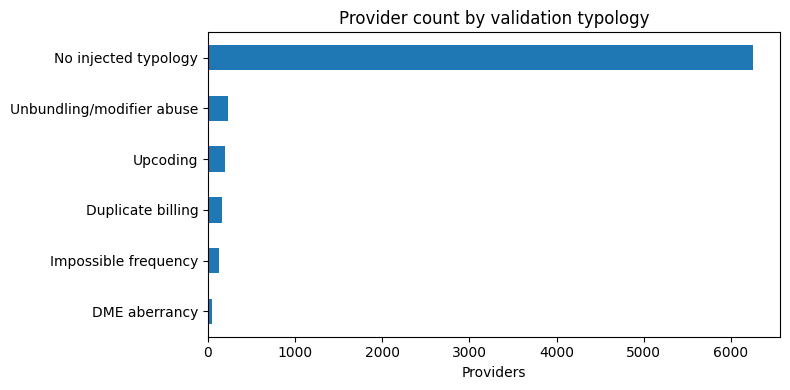

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
df["injected_typology"].value_counts().sort_values().plot(kind="barh", ax=ax)
ax.set_title("Provider count by validation typology")
ax.set_xlabel("Providers")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 4. Fit HUG-IML model and select governed threshold

The model is trained only on operationally interpretable provider-level indicators. The decision threshold is selected to satisfy a minimum priority precision constraint, which helps control unnecessary escalation and reviewer burden. If no threshold satisfies the constraint, the procedure falls back to the best F1 threshold and records that exception.

In [6]:
X = df[PREDICTORS]
y = df[TARGET]

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    df.index,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

clf = HUGIMLClassifier(
    B=12,
    L=2,
    G=0.00003,
    topK=160,
    adaptive_binning=True,
    b_candidates=[6, 8, 10, 12],
    n_jobs=1,
)
clf.fit(X_train, y_train)
scores = clf.predict_proba(X_test)[:, 1]
threshold, threshold_policy = choose_threshold(y_test, scores, min_precision=MIN_PRIORITY_PRECISION)
pred = (scores >= threshold).astype(int)

metrics = {
    "AUC": roc_auc_score(y_test, scores),
    "Average precision": average_precision_score(y_test, scores),
    "Priority precision": precision_score(y_test, pred),
    "Priority recall": recall_score(y_test, pred),
    "Priority F1": f1_score(y_test, pred),
    "Governed threshold": threshold,
    "Threshold policy": threshold_policy,
    "HUG-IML pattern count": len(clf.get_hug_features()),
}

metrics_table = pd.DataFrame([metrics]).T.reset_index()
metrics_table.columns = ["measure", "value"]
metrics_table["value"] = metrics_table["value"].apply(lambda v: f"{v:,.4f}" if isinstance(v, float) else v)
display(metrics_table)

,measure,value
0,AUC,0.9686
1,Average precision,0.7720
2,Priority precision,0.8447
3,Priority recall,0.6044
4,Priority F1,0.7047
5,Governed threshold,0.5805
6,Threshold policy,minimum_precision
7,HUG-IML pattern count,115


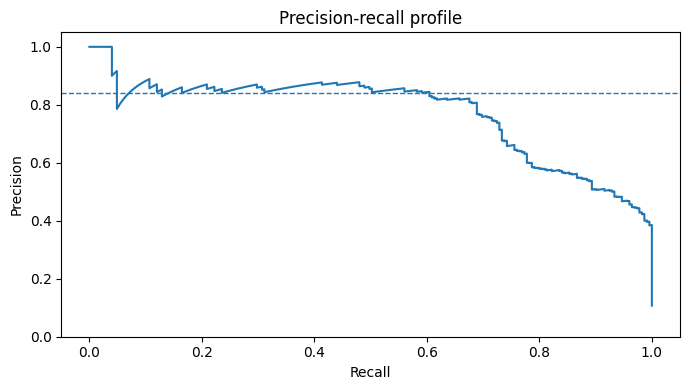

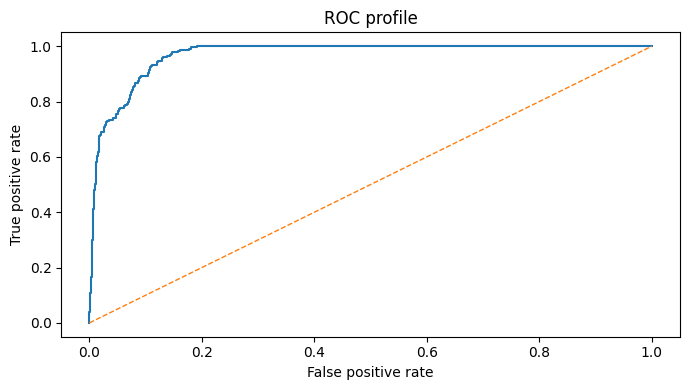

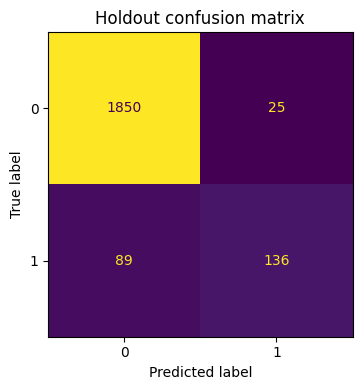

In [7]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, scores)
fpr, tpr, roc_thresholds = roc_curve(y_test, scores)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(recall_curve, precision_curve)
ax.axhline(MIN_PRIORITY_PRECISION, linestyle="--", linewidth=1)
ax.set_title("Precision-recall profile")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
ax.set_title("ROC profile")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax, colorbar=False)
ax.set_title("Holdout confusion matrix")
plt.tight_layout()
plt.show()

## 5. Queue governance and financial materiality

The holdout scores are converted into operational tiers. The highest tier is the governed investigation queue, while lower tiers support desk review, monitoring, sampling, or no action depending on reviewer capacity and policy constraints.

In [8]:
holdout = df.loc[idx_test].copy()
holdout["score"] = scores
holdout["prediction"] = pred
holdout["actual"] = y_test.values

# Tiers are score-based and separate operational workload from the binary threshold decision.
holdout["queue_tier"] = pd.qcut(
    holdout["score"],
    q=[0, 0.55, 0.80, 0.93, 1.0],
    labels=["Monitor", "Desk review", "Case review", "Priority investigation"],
    duplicates="drop",
)

queue_summary = holdout.groupby("queue_tier", observed=True).agg(
    providers=("provider_id", "count"),
    known_merit_rate=("actual", "mean"),
    avg_score=("score", "mean"),
    predicted_review_rate=("prediction", "mean"),
    total_allowed=("total_allowed_amount", "sum"),
    avg_denial_rate=("denial_rate", "mean"),
).reset_index()

queue_summary_display = queue_summary.copy()
for col in ["known_merit_rate", "predicted_review_rate", "avg_denial_rate"]:
    queue_summary_display[col] = queue_summary_display[col].map(pct)
queue_summary_display["avg_score"] = queue_summary_display["avg_score"].map(lambda x: f"{x:,.3f}")
queue_summary_display["total_allowed"] = queue_summary_display["total_allowed"].map(money)

display(queue_summary_display)
queue_summary.to_csv(OUTPUT_DIR / "queue_governance_summary.csv", index=False)

selected_exposure = holdout.loc[holdout["prediction"] == 1, "total_allowed_amount"].sum()
selected_count = int(holdout["prediction"].sum())
selected_merit_rate = holdout.loc[holdout["prediction"] == 1, "actual"].mean()

display(Markdown(
    f"**Governed queue:** {selected_count:,} providers selected, "
    f"{pct(selected_merit_rate)} known-merit rate, "
    f"{money(selected_exposure)} selected allowed exposure."
))

,queue_tier,providers,known_merit_rate,avg_score,predicted_review_rate,total_allowed,avg_denial_rate
0,Monitor,1155,0.0%,0.005,0.0%,"$539,149,936",10.8%
1,Desk review,525,2.9%,0.028,0.0%,"$251,172,052",12.0%
2,Case review,273,30.8%,0.275,5.1%,"$145,625,150",12.9%
3,Priority investigation,147,85.7%,0.857,100.0%,"$101,092,269",12.6%


**Governed queue:** 161 providers selected, 84.5% known-merit rate, $107,189,105 selected allowed exposure.

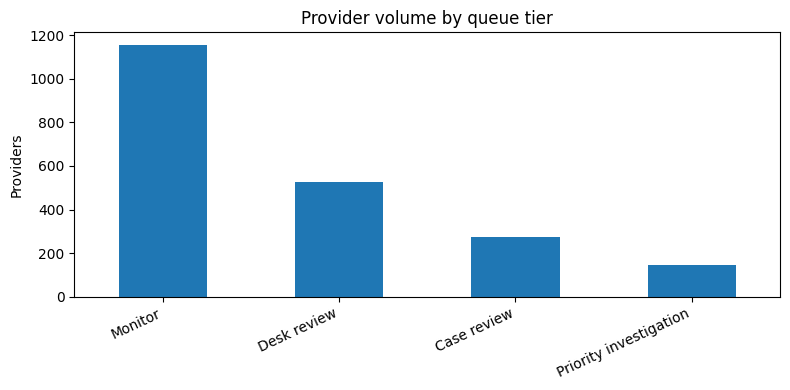

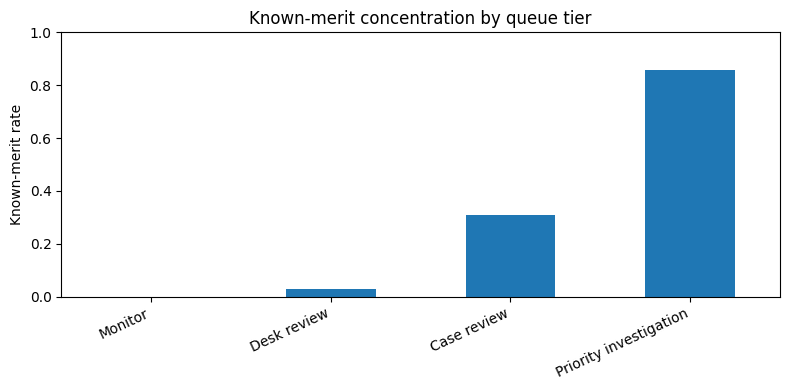

In [9]:
plot_queue = queue_summary.set_index("queue_tier")
fig, ax = plt.subplots(figsize=(8, 4))
plot_queue["providers"].plot(kind="bar", ax=ax)
ax.set_title("Provider volume by queue tier")
ax.set_xlabel("")
ax.set_ylabel("Providers")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
plot_queue["known_merit_rate"].plot(kind="bar", ax=ax)
ax.set_title("Known-merit concentration by queue tier")
ax.set_xlabel("")
ax.set_ylabel("Known-merit rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 6. Explainability: HUG-IML pattern evidence

HUG-IML produces explicit pattern features. The coefficient table below ranks the strongest positive and negative patterns by absolute coefficient. Positive coefficients raise review priority; negative coefficients reduce review priority. These patterns provide a transparent starting point for reviewer evidence gathering.

In [10]:
patterns = pd.DataFrame({
    "pattern": clf.get_hug_features(),
    "coefficient": clf.model_.named_steps["clf"].coef_[0],
})
patterns["abs_coefficient"] = patterns["coefficient"].abs()
patterns["case_review_reading"] = np.where(
    patterns["coefficient"] > 0,
    "Raises priority",
    "Reduces priority",
)
patterns = patterns.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

top_patterns = patterns.head(20).copy()
top_patterns["coefficient"] = top_patterns["coefficient"].map(lambda x: f"{x:+,.3f}")
top_patterns["abs_coefficient"] = top_patterns["abs_coefficient"].map(lambda x: f"{x:,.3f}")
display(top_patterns)
patterns.to_csv(OUTPUT_DIR / "hugiml_pattern_evidence.csv", index=False)

,pattern,coefficient,abs_coefficient,case_review_reading
0,"peer_z_allowed=[1.98,11.41)",+4.086,4.086,Raises priority
1,"duplicate_claim_rate=[0.098,0.679)",+3.461,3.461,Raises priority
2,"weekend_service_rate=[0.17,0.928)",+2.931,2.931,Raises priority
3,"modifier_59_rate=[0.2688,1)",+1.662,1.662,Raises priority
4,"high_level_code_rate=[0.417,1)",+1.441,1.441,Raises priority
5,"peer_z_allowed=[0.34,0.57)",-1.119,1.119,Reduces priority
6,"peer_z_allowed=[-3.59,-1.287)",-0.838,0.838,Reduces priority
7,"modifier_59_rate=[0.078,0.0955)",-0.794,0.794,Reduces priority
8,"peer_z_allowed=[-1.287,-0.89)",-0.737,0.737,Reduces priority
9,"peer_z_allowed=[-0.61,-0.35)",-0.716,0.716,Reduces priority


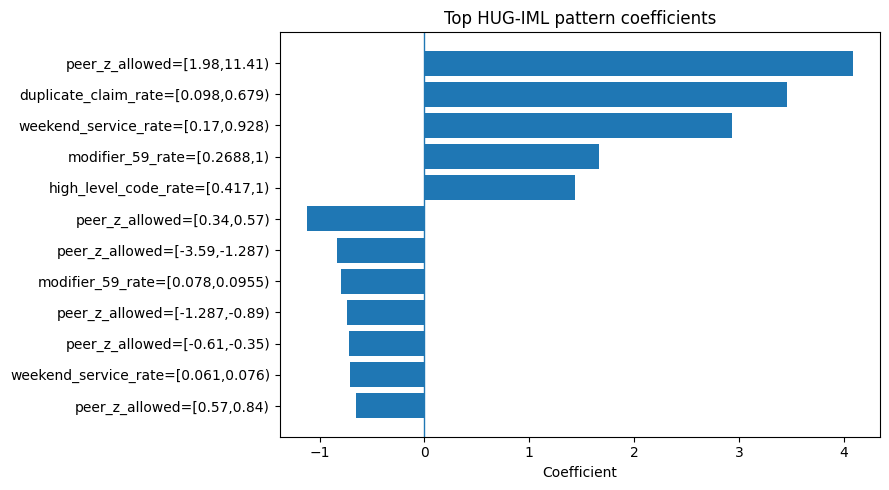

In [11]:
plot_patterns = patterns.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_patterns["pattern"], plot_patterns["coefficient"])
ax.axvline(0, linewidth=1)
ax.set_title("Top HUG-IML pattern coefficients")
ax.set_xlabel("Coefficient")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 7. Specialty and typology review

Specialty-level review rates help compliance teams monitor operational concentration and peer-group reasonableness. Typology capture is a validation lens only; lower-capture typologies should be handled through complementary rules, targeted sampling, or additional evidence sources.

In [12]:
specialty_summary = holdout.groupby("specialty", observed=True).agg(
    providers=("provider_id", "count"),
    review_rate=("prediction", "mean"),
    known_merit_rate=("actual", "mean"),
    avg_score=("score", "mean"),
    allowed=("total_allowed_amount", "sum"),
).reset_index().sort_values(["review_rate", "known_merit_rate"], ascending=False)

typology_summary = holdout.groupby("injected_typology", observed=True).agg(
    cases=("provider_id", "count"),
    capture_rate=("prediction", "mean"),
    avg_score=("score", "mean"),
    selected_allowed=("total_allowed_amount", lambda s: s[holdout.loc[s.index, "prediction"] == 1].sum()),
).reset_index().sort_values("capture_rate", ascending=False)

specialty_display = specialty_summary.copy()
for col in ["review_rate", "known_merit_rate"]:
    specialty_display[col] = specialty_display[col].map(pct)
specialty_display["avg_score"] = specialty_display["avg_score"].map(lambda x: f"{x:,.3f}")
specialty_display["allowed"] = specialty_display["allowed"].map(money)

typology_display = typology_summary.copy()
typology_display["capture_rate"] = typology_display["capture_rate"].map(pct)
typology_display["avg_score"] = typology_display["avg_score"].map(lambda x: f"{x:,.3f}")
typology_display["selected_allowed"] = typology_display["selected_allowed"].map(money)

display(Markdown("**Specialty review summary**"))
display(specialty_display)
display(Markdown("**Validation typology capture summary**"))
display(typology_display)

specialty_summary.to_csv(OUTPUT_DIR / "specialty_review_summary.csv", index=False)
typology_summary.to_csv(OUTPUT_DIR / "typology_capture_summary.csv", index=False)

**Specialty review summary**

,specialty,providers,review_rate,known_merit_rate,avg_score,allowed
1,DME Supplier,192,14.1%,20.8%,0.173,"$91,129,678"
3,Internal Medicine,420,8.3%,10.2%,0.114,"$215,761,215"
0,Cardiology,239,7.9%,10.0%,0.103,"$131,871,493"
8,Radiology,227,7.9%,10.6%,0.103,"$101,814,294"
7,Pain Management,176,6.8%,8.0%,0.085,"$90,871,519"
5,Oncology,180,6.7%,8.3%,0.095,"$100,641,508"
6,Orthopedics,245,6.5%,11.4%,0.094,"$106,526,420"
2,Home Health,210,5.2%,8.1%,0.099,"$101,778,683"
4,Lab,211,5.2%,9.5%,0.077,"$96,644,596"


**Validation typology capture summary**

,injected_typology,cases,capture_rate,avg_score,selected_allowed
5,Upcoding,62,88.7%,0.783,"$38,981,730"
4,Unbundling/modifier abuse,68,86.8%,0.793,"$44,788,005"
0,DME aberrancy,16,50.0%,0.567,"$3,852,208"
1,Duplicate billing,42,26.2%,0.418,"$7,435,090"
2,Impossible frequency,37,8.1%,0.210,"$1,608,800"
3,No injected typology,1875,1.3%,0.045,"$10,523,270"


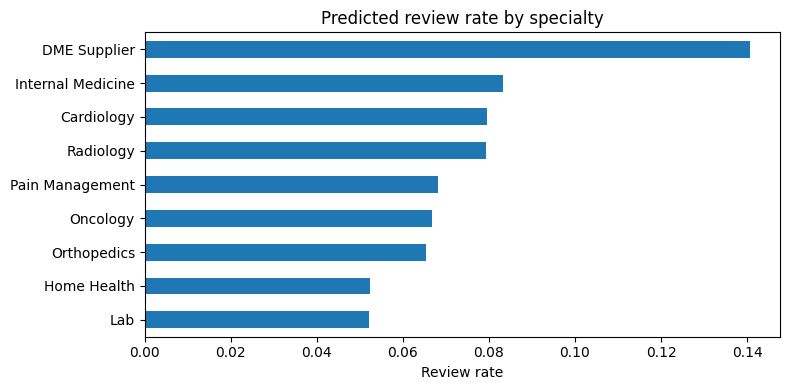

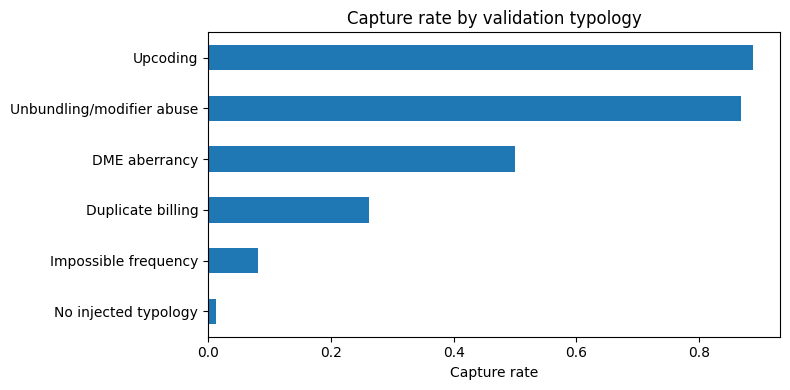

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
specialty_summary.set_index("specialty")["review_rate"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Predicted review rate by specialty")
ax.set_xlabel("Review rate")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
typology_summary.set_index("injected_typology")["capture_rate"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Capture rate by validation typology")
ax.set_xlabel("Capture rate")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 8. Reviewer operating pack

The operating pack translates model output into a review workflow. It identifies providers in the governed queue, attaches the strongest visible billing indicators, and records the score, tier, validation label, and financial exposure needed for reviewer triage.

In [14]:
positive_patterns = patterns.loc[patterns["coefficient"] > 0].head(8)["pattern"].tolist()

reviewer_pack_columns = [
    "provider_id",
    "specialty",
    "region",
    "score",
    "queue_tier",
    "actual",
    "injected_typology",
    "beneficiary_count",
    "claims_per_beneficiary",
    "avg_allowed_amount",
    "risk_adjustment_score",
    "high_level_code_rate",
    "duplicate_claim_rate",
    "modifier_59_rate",
    "weekend_service_rate",
    "denial_rate",
    "referral_concentration",
    "peer_z_allowed",
    "total_allowed_amount",
]

reviewer_pack = holdout.loc[holdout["prediction"] == 1, reviewer_pack_columns].sort_values(
    ["score", "total_allowed_amount"], ascending=False
).reset_index(drop=True)
reviewer_pack["rank"] = np.arange(1, len(reviewer_pack) + 1)
reviewer_pack = reviewer_pack[["rank"] + reviewer_pack_columns]

reviewer_pack_display = reviewer_pack.head(25).copy()
reviewer_pack_display["score"] = reviewer_pack_display["score"].map(lambda x: f"{x:,.3f}")
reviewer_pack_display["total_allowed_amount"] = reviewer_pack_display["total_allowed_amount"].map(money)
display(reviewer_pack_display)
reviewer_pack.to_csv(OUTPUT_DIR / "reviewer_operating_pack.csv", index=False)

display(Markdown("**Primary evidence themes for case sampling**"))
for pattern in positive_patterns:
    display(Markdown(f"- `{pattern}`"))

,rank,provider_id,specialty,region,score,queue_tier,actual,injected_typology,beneficiary_count,claims_per_beneficiary,avg_allowed_amount,risk_adjustment_score,high_level_code_rate,duplicate_claim_rate,modifier_59_rate,weekend_service_rate,denial_rate,referral_concentration,peer_z_allowed,total_allowed_amount
0,1,NPI2000004223,Home Health,Midwest,0.999,Priority investigation,1,Duplicate billing,457,6.0200,700.4200,1.2300,0.0930,0.3530,0.7320,0.0970,0.2630,0.2070,3.9100,"$2,375,738"
1,2,NPI2000005940,Internal Medicine,South,0.999,Priority investigation,1,Upcoding,331,5.4000,801.9300,0.5500,0.7690,0.4620,0.1120,0.0420,0.3580,0.3740,5.0400,"$788,328"
2,3,NPI2000001222,DME Supplier,Midwest,0.998,Priority investigation,1,Unbundling/modifier abuse,163,9.4700,"1,014.4400",1.0200,0.1990,0.0720,0.5440,0.1740,0.0570,0.3480,3.9400,"$1,595,351"
3,4,NPI2000003026,Pain Management,South,0.997,Priority investigation,1,Unbundling/modifier abuse,115,6.8700,"1,121.3700",1.1500,0.1280,0.0990,0.6740,0.0680,0.1020,0.1850,3.9600,"$1,020,028"
4,5,NPI2000000659,DME Supplier,Midwest,0.997,Priority investigation,1,Unbundling/modifier abuse,132,6.9500,797.2900,0.5600,0.1120,0.0080,0.9580,0.2080,0.0750,0.2450,3.6200,"$413,180"
5,6,NPI2000001618,Orthopedics,South,0.996,Priority investigation,1,Unbundling/modifier abuse,101,5.1000,477.1400,0.9600,0.3300,0.1290,0.6600,0.0090,0.1140,0.3900,3.3000,"$236,549"
6,7,NPI2000006306,Pain Management,South,0.996,Priority investigation,1,Duplicate billing,113,4.1700,702.7300,1.1400,0.1370,0.3080,0.6980,0.0920,0.0470,0.2680,3.2900,"$375,878"
7,8,NPI2000001359,Cardiology,Northeast,0.996,Priority investigation,1,Unbundling/modifier abuse,61,4.5400,327.7800,0.9600,0.0950,0.0980,0.5240,0.0380,0.1440,0.2340,3.2500,"$87,017"
8,9,NPI2000003992,Oncology,South,0.995,Priority investigation,1,Unbundling/modifier abuse,126,4.7600,932.9200,1.1000,0.2600,0.0470,0.5310,0.1920,0.0890,0.4420,4.6200,"$615,668"
9,10,NPI2000006851,Pain Management,South,0.995,Priority investigation,0,No injected typology,93,6.1700,503.9500,0.8600,0.1140,0.1610,0.2860,0.0180,0.1030,0.2680,2.4100,"$247,681"


**Primary evidence themes for case sampling**

- `peer_z_allowed=[1.98,11.41)`

- `duplicate_claim_rate=[0.098,0.679)`

- `weekend_service_rate=[0.17,0.928)`

- `modifier_59_rate=[0.2688,1)`

- `high_level_code_rate=[0.417,1)`

- `denial_rate=[0.24,0.767)`

- `referral_concentration=[0.138,0.167)`

- `total_allowed_amount=[5.529e+05,7.023e+05)`

## 9. Governance interpretation and controls

**Queue usefulness.** The model has strong holdout discrimination and materially improves case concentration compared with unguided review. Its approval case rests on precision, queue yield, capacity, and interpretability rather than AUC alone.

**Evidence sufficiency.** The highest-ranked HUG-IML patterns are tied to reviewable billing behavior: specialty peer deviation, duplicate-like claim behavior, modifier use, coding intensity, weekend service patterns, denial rates, and utilization indicators. These are suitable for reviewer workpapers because they can be translated into claim samples and peer comparisons.

**False-positive control.** The governed threshold enforces a minimum precision constraint. Lower score tiers should remain monitoring, sampling, or desk-review workflows unless additional evidence is available.

**Specialty monitoring.** Specialty concentration must be reviewed carefully. Elevated review rates may be appropriate when merit rates and peer-deviation evidence are also elevated, but reviewers should validate specialty peer-group definitions and clinical context.

**Typology coverage.** The queue is strongest for typologies with clear signal in the provider-level indicators. Lower-capture typologies should be supported with complementary rules, claim-line edits, targeted sampling, or additional data sources.

**Operational boundary.** The screen supports triage and evidence organization. It does not support final fraud determinations, payment suspension, or enforcement action without claim-line corroboration and documented human review.

In [15]:
run_manifest = {
    "random_state": RANDOM_STATE,
    "test_size": 0.30,
    "minimum_priority_precision": MIN_PRIORITY_PRECISION,
    "threshold": threshold,
    "threshold_policy": threshold_policy,
    "metrics": metrics,
    "predictors": PREDICTORS,
    "excluded_fields": LEAKAGE_EXCLUSIONS,
    "output_files": sorted(p.name for p in OUTPUT_DIR.glob("*.csv")),
}
with open(OUTPUT_DIR / "run_manifest.json", "w", encoding="utf-8") as f:
    json.dump(run_manifest, f, indent=2, default=str)

display(Markdown("**Generated audit artifacts**"))
for p in sorted(OUTPUT_DIR.glob("*")):
    display(Markdown(f"- `{p.as_posix()}`"))

**Generated audit artifacts**

- `outputs/feature_governance_register.csv`

- `outputs/hugiml_pattern_evidence.csv`

- `outputs/queue_governance_summary.csv`

- `outputs/reviewer_operating_pack.csv`

- `outputs/run_manifest.json`

- `outputs/specialty_review_summary.csv`

- `outputs/typology_capture_summary.csv`